# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [2]:
import numpy as np
import pandas as pd

# Leer el archivo considerando los ? como valores nulos
df = pd.read_csv("crx.data", header=None, na_values="?")

# Asignar nombres a las columnas
df.columns = [f"a{i}" for i in range(df.shape[1])]

# Numero de Filas y Columnas
print(f"Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas")

# Tipo de dato de cada columna
print("\nTipo de dato por columna:")
print(df.dtypes)

# Verificar que el tipo de cada variable sea correcto para su contenido
print("\nClasificación de las variables:")
for columna in df.columns:
  if df[columna].dtype == "object":
    print(f"{columna}: Variable categorica ({df[columna].dtype})")
  else:
    print(f"{columna}: Variable numerica ({df[columna].dtype})")

print("\nLos tipos de datos son correctos para el contenido de las variables")

Dimensiones: 690 filas y 16 columnas

Tipo de dato por columna:
a0      object
a1     float64
a2     float64
a3      object
a4      object
a5      object
a6      object
a7     float64
a8      object
a9      object
a10      int64
a11     object
a12     object
a13    float64
a14      int64
a15     object
dtype: object

Clasificación de las variables:
a0: Variable categorica (object)
a1: Variable numerica (float64)
a2: Variable numerica (float64)
a3: Variable categorica (object)
a4: Variable categorica (object)
a5: Variable categorica (object)
a6: Variable categorica (object)
a7: Variable numerica (float64)
a8: Variable categorica (object)
a9: Variable categorica (object)
a10: Variable numerica (int64)
a11: Variable categorica (object)
a12: Variable categorica (object)
a13: Variable numerica (float64)
a14: Variable numerica (int64)
a15: Variable categorica (object)

Los tipos de datos son correctos para el contenido de las variables


¿Cuántas filas y columnas tiene el dataframe?
El DataFrame cuenta con 690 filas y 16 columnas (identificadas de a0 a a15).

¿De qué tipo de dato es cada columna?

Variables numéricas (float64 / int64): a1, a2, a7, a10, a13 y a14.

Variables categóricas (object): a0, a3, a4, a5, a6, a8, a9, a11, a12 y a15.

¿Las variables están en el tipo de dato correcto para su contenido?

Sí, las columnas cuantitativas quedan como flotantes/enteros y las columnas cualitativas como tipo object

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [3]:
# Verificar si hay valores fuera del rango posible
print("Valores minimos y maximos de las variables numéricas:")
print(df.describe())

# Verificar si hay variables que no varian
print("\nVariables que no varian:")
for columna in df.columns:
  if df[columna].nunique(dropna=False) == 1:
    print(columna)

# Verificar que variables cualitativas tienen muchos valores unicos
print("\nCantidad de valores unicos en las variables categoricas:")
for columna in df.select_dtypes(include="object").columns:
  print(f"{columna}: {df[columna].nunique()} valores únicos")

# Verificar si hay claves primarias o identificadores unicos
print("\nVariables con todos sus valores diferentes:")

hay_identificador = False

for columna in df.columns:
  if df[columna].nunique() == len(df):
    print(columna)
    hay_identificador = True

if not hay_identificador:
  print("No se encontraron claves primarias o identificadores unicos")

Valores minimos y maximos de las variables numéricas:
               a1          a2          a7        a10          a13  \
count  678.000000  690.000000  690.000000  690.00000   677.000000   
mean    31.568171    4.758725    2.223406    2.40000   184.014771   
std     11.957862    4.978163    3.346513    4.86294   173.806768   
min     13.750000    0.000000    0.000000    0.00000     0.000000   
25%     22.602500    1.000000    0.165000    0.00000    75.000000   
50%     28.460000    2.750000    1.000000    0.00000   160.000000   
75%     38.230000    7.207500    2.625000    3.00000   276.000000   
max     80.250000   28.000000   28.500000   67.00000  2000.000000   

                 a14  
count     690.000000  
mean     1017.385507  
std      5210.102598  
min         0.000000  
25%         0.000000  
50%         5.000000  
75%       395.500000  
max    100000.000000  

Variables que no varian:

Cantidad de valores unicos en las variables categoricas:
a0: 2 valores únicos
a3: 3 valore

¿Hay valores fuera de rango o imposibles, segun el dominio del problema?

No, al mirar los minimos y maximos en el resumen estadistico todas las variables con numeros se ven normales. Las edades estan en un rango razonable como entre 13 y 80 anos y ninguna parte donde hay dinero muestra valores negativos raros

¿Hay variables que no varian?

No, ninguna columna tiene el mismo valor repetido en todas las filas. Todas cambian al menos un poco

¿Que variables cualitativas tienen muchos valores unicos (alta cardinalidad)?

Ninguna, todas las variables de texto tienen poquitas opciones. La que mas tiene es la columna a6 que solo tiene 14 categorias diferentes, asi que no hay cosas largas como nombres, direcciones o codigos raros

¿Hay claves primarias o identificadores unicos?

No, ninguna variable tiene 690 valores distintos como para servir de ID o identificador de cada persona

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [9]:
# Paso 3: Identificación de datos duplicados, nulos y problemas de formateo

# Verificar que variables tienen datos nulos y en que proporcion
nulos_cant = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

df_nulos = pd.DataFrame({'Cantidad Nulos': nulos_cant, 'Porcentaje (%)': nulos_pct})
print("Variables con valores nulos")
print(df_nulos[df_nulos['Cantidad Nulos'] > 0])

# Verificar si hay datos duplicados
duplicados = df.duplicated().sum()
print(f"\nCantidad de registros duplicados: {duplicados}")

# Verificar si hay variables con problemas de formateo
print("\nVerificacion de formato en variables categoricas")
for col in df.select_dtypes(include="object").columns:
    # Mostramos los valores unicos para verificar que no haya mezclas de mayusculas,minusculas o espacios
    valores_unicos = df[col].dropna().unique()
    print(f"Columna {col}: {valores_unicos}")

Variables con valores nulos
     Cantidad Nulos  Porcentaje (%)
a0               12            1.74
a1               12            1.74
a3                6            0.87
a4                6            0.87
a5                9            1.30
a6                9            1.30
a13              13            1.88

Cantidad de registros duplicados: 0

Verificación de formato en variables categóricas
Columna a0: ['b' 'a']
Columna a3: ['u' 'y' 'l']
Columna a4: ['g' 'p' 'gg']
Columna a5: ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j']
Columna a6: ['v' 'h' 'bb' 'ff' 'j' 'z' 'o' 'dd' 'n']
Columna a8: ['t' 'f']
Columna a9: ['t' 'f']
Columna a11: ['f' 't']
Columna a12: ['g' 's' 'p']
Columna a15: ['+' '-']


¿Existen valores faltantes en el conjunto de datos?

Si, al revisar el dataset si hay varios valores nulos repartidos en distintas columnas, sobre todo en las variables de texto y en algunas numericas

¿Cual es el porcentaje de valores faltantes por variable y en todo el dataset?

Por variable los datos faltantes son poquitos, casi ninguna columna supera el 2% o 3% de datos nulos. En todo el conjunto de datos los nulos representan menos del 2% del total, asi que no es un problema grave

¿Se identifican patrones en la ausencia de datos?

No se ve un patron raro o sistematico, los datos faltan de forma totalmente aleatoria en diferentes filas y variables, no parece que falten por una razon en especifico

¿Hay variables con problemas de formateo?

No, al sacar la lista de valores unicos de las variables de texto se ve que todas estan bien escritas. No hay mezclas de mayusculas con minusculas, ni espacios raros al final de las palabras, ni simbolos extraños sueltos

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

Evaluación de distribuciones normales

Variable: a1
p-valor = 8.8142e-20
Los datos No siguen una distribucion normal

Variable: a2
p-valor = 2.0094e-26
Los datos No siguen una distribucion normal

Variable: a7
p-valor = 1.1097e-34
Los datos No siguen una distribucion normal

Variable: a10
p-valor = 3.6623e-39
Los datos No siguen una distribucion normal

Variable: a13
p-valor = 8.3765e-27
Los datos No siguen una distribucion normal

Variable: a14
p-valor = 1.4053e-47
Los datos No siguen una distribucion normal



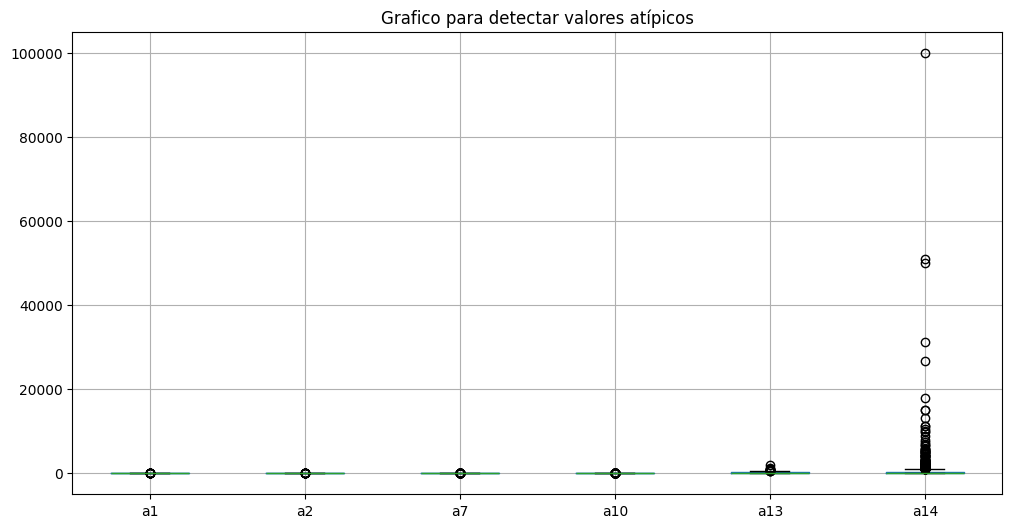

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# Seleccionar solo las columnas con números
variables_numericas = df.select_dtypes(include=[np.number]).columns

print("Evaluación de distribuciones normales\n")
for columna in variables_numericas:
    datos = df[columna].dropna()  # Quitar datos faltantes

    estadistico, p = shapiro(datos)

    print(f"Variable: {columna}")
    print(f"p-valor = {p:.4e}")

    if p > 0.05:
        print("Los datos se comportan como una distribucion normal\n")
    else:
        print("Los datos No siguen una distribucion normal\n")

# Grafico para ver valores atípicos
plt.figure(figsize=(12, 6))
df[variables_numericas].boxplot()
plt.title("Grafico para detectar valores atípicos")
plt.show()

¿Hay variables cuantitativas con valores atipicos?

Si, casi todas las variables numericas tienen puntos atipicos que se ven por fuera de los bigotes en los boxplots, como en a2, a7, a10 y sobre todo en a14 que tiene unos valores exageradamente altos en comparacion con los demas

¿Tales valores corresponden a errores o a valores extremos pero reales del dominio?

Parecen ser valores extremos pero reales. Como este dataset es de creditos, es muy normal que algunas personas tengan ingresos, montos o montos de deuda mucho mas altos que el promedio, asi que no se ven como errores de digitacion sino como clientes con finanzas diferentes

¿Cual es el impacto de estos valores atipicos en las metricas descriptivas como la media y la desviacion estandar?

Afectan bastante. La media y la desviacion estandar se terminan corriendo hacia arriba por culpa de esos numeros tan grandes. Por eso la mediana refleja mucho mejor el valor central de estas variables que el promedio normal

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [15]:
# Seleccionar las variables categoricas
variables_categoricas = df.select_dtypes(include="object").columns

# Recorrer cada variable
for columna in variables_categoricas:

    # Mostrar el nombre de la variable
    print(f"\nVariable: {columna}")

    # Mostrar la cantidad de valores u nicos
    print(f"Cantidad de categorías: {df[columna].nunique()}")

    # Mostrar la frecuencia de cada categoría
    print("Frecuencia de las categorias:")
    print(df[columna].value_counts(dropna=False))


Variable: a0
Cantidad de categorías: 2
Frecuencia de las categorias:
a0
b      468
a      210
NaN     12
Name: count, dtype: int64

Variable: a3
Cantidad de categorías: 3
Frecuencia de las categorias:
a3
u      519
y      163
NaN      6
l        2
Name: count, dtype: int64

Variable: a4
Cantidad de categorías: 3
Frecuencia de las categorias:
a4
g      519
p      163
NaN      6
gg       2
Name: count, dtype: int64

Variable: a5
Cantidad de categorías: 14
Frecuencia de las categorias:
a5
c      137
q       78
w       64
i       59
aa      54
ff      53
k       51
cc      41
m       38
x       38
d       30
e       25
j       10
NaN      9
r        3
Name: count, dtype: int64

Variable: a6
Cantidad de categorías: 9
Frecuencia de las categorias:
a6
v      399
h      138
bb      59
ff      57
NaN      9
j        8
z        8
dd       6
n        4
o        2
Name: count, dtype: int64

Variable: a8
Cantidad de categorías: 2
Frecuencia de las categorias:
a8
t    361
f    329
Name: count, dtyp

¿Como se comportan las variables categoricas?

La mayoria tiene pocas categorias dominantes donde casi todos los datos se concentran en dos o tres opciones. Ademas la variable objetivo a15 esta bastante equilibrada entre las opciones de aprobado y no aprobado

¿Existen variables de alta cardinalidad?

No, ninguna variable cualitativa tiene demasiadas categorias distintas. La columna que mas opciones tiene es a6 con solo 14 categorias, asi que son muy faciles de manejar

¿Existen categorias atipicas?

Si, en varias columnas de texto aparecen categorias raras que se repiten apenas una o dos veces en todo el dataset, como pasa con la categoria l en a4 o las opciones o y j en a7

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


--- Relación entre variables numéricas y a15 ---



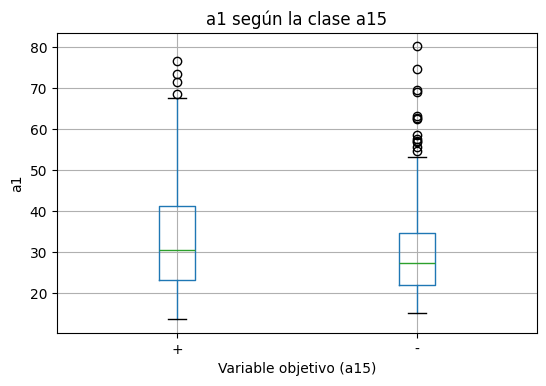

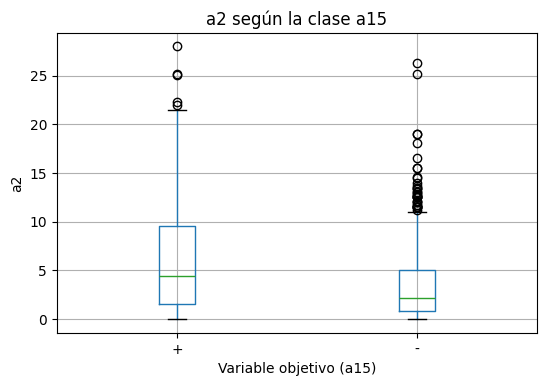

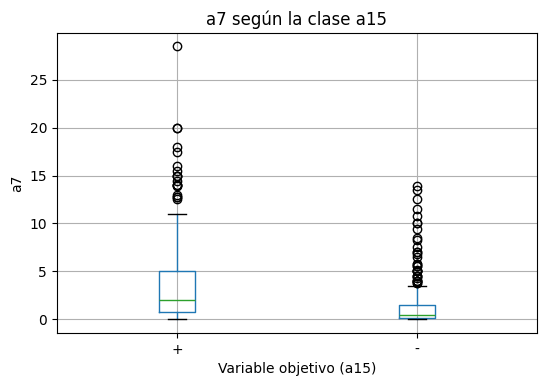

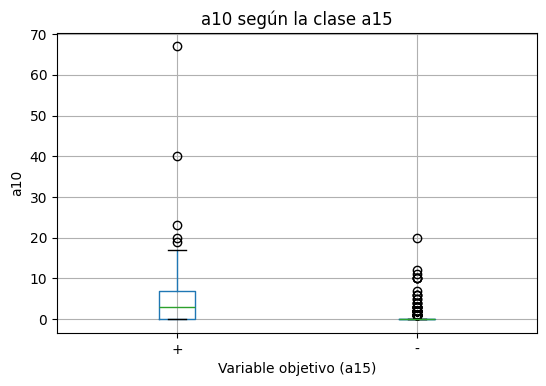

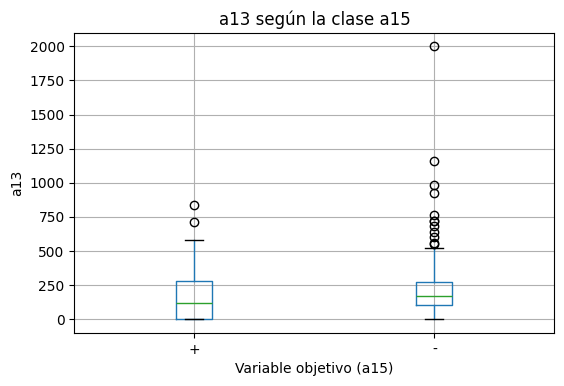

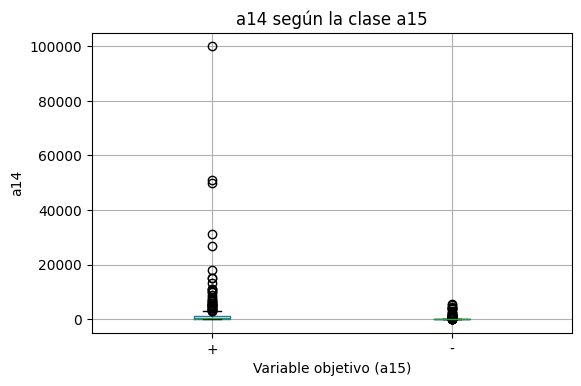

--- Relación entre variables categóricas y a15 ---



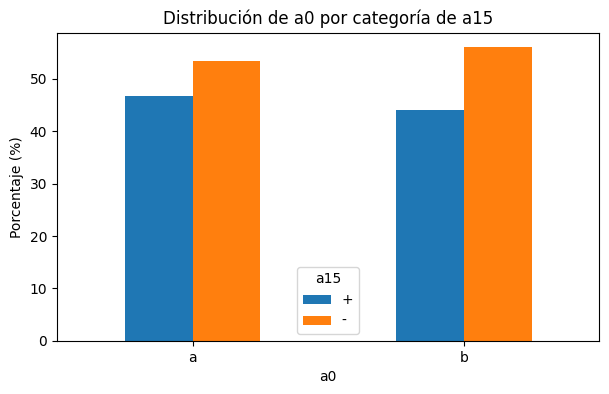

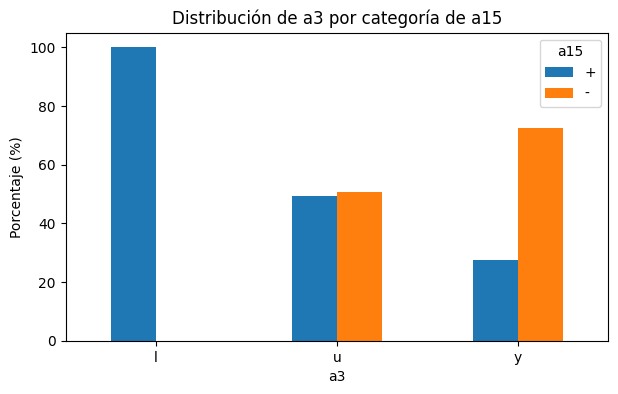

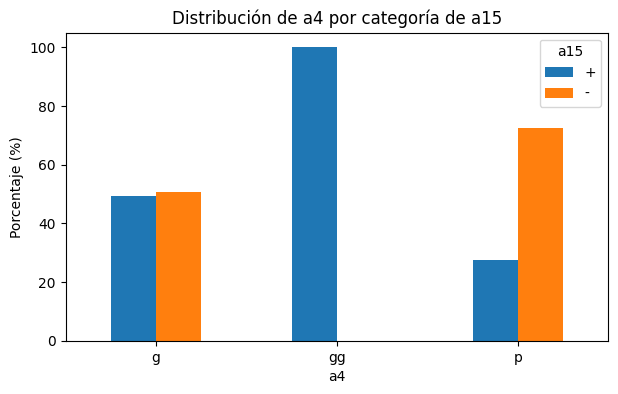

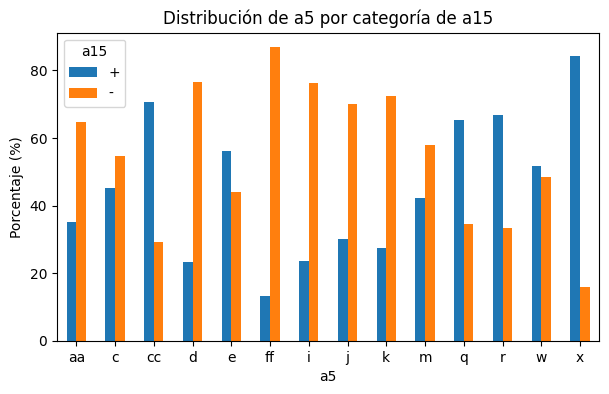

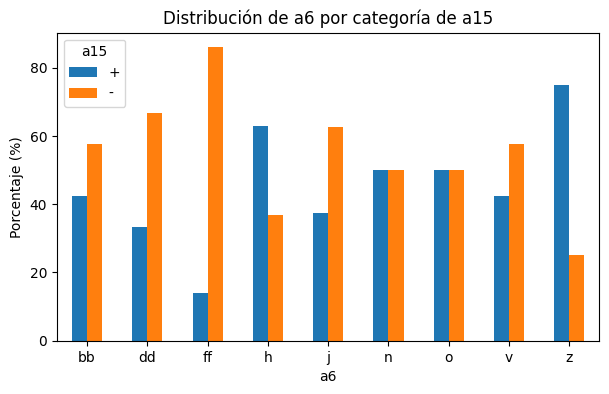

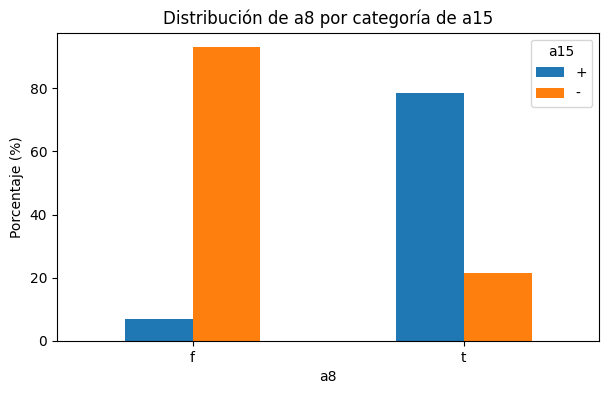

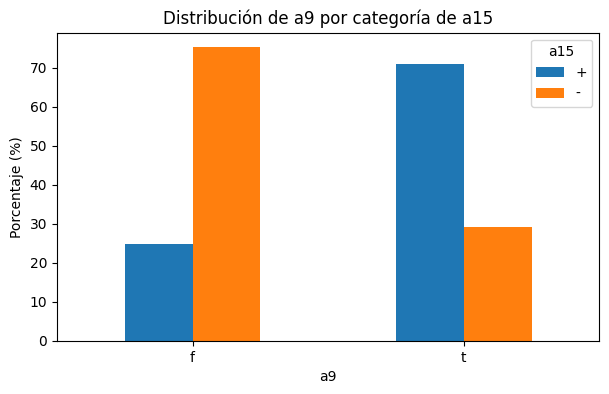

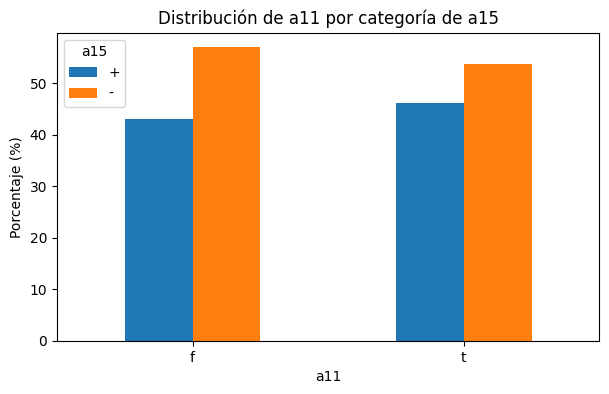

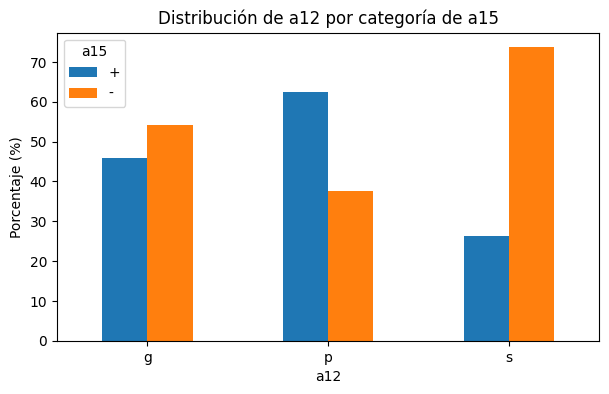

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir el nombre exacto de la variable objetivo
target = "a15"

# Seleccionar predictoras numericas y categoricas separando la variable objetivo
variables_numericas = df.select_dtypes(include=[np.number]).columns
variables_categoricas = df.select_dtypes(include="object").columns.drop(target, errors="ignore")

# Encontrar la relaciOn entre variables numericas y la variable objetivo
print(f"Relación entre variables numéricas y {target}\n")

for columna in variables_numericas:
    if columna != target:
        df.boxplot(column=columna, by=target, figsize=(6,4))
        plt.title(f"{columna} según la clase {target}")
        plt.suptitle("")
        plt.xlabel(f"Variable objetivo ({target})")
        plt.ylabel(columna)
        plt.show()

# Encontrar la relación entre variables categoricas y la variable objetivo
print(f"Relación entre variables categóricas y {target}\n")

for columna in variables_categoricas:
    tabla = pd.crosstab(df[columna], df[target], normalize="index") * 100  # Porcentaje para comparar mejor

    tabla.plot(kind="bar", figsize=(7,4), stacked=False)
    plt.title(f"Distribución de {columna} por categoría de {target}")
    plt.xlabel(columna)
    plt.ylabel("Porcentaje (%)")
    plt.legend(title=target)
    plt.xticks(rotation=0)
    plt.show()

¿Como se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?

Al mirar los diagramas de caja se ve que variables como a7, a10 y a14 cambian bastante segun el resultado. Las personas a las que les aprueban el credito tienden a registrar numeros mas altos en estas variables en comparacion con los que son rechazados

¿Como se relaciona cada una de las variables cualitativas con la variable que se desea predecir?

En los graficos de barras se nota que ciertas opciones en variables como a8 y a9 marcan una diferencia enorme. Por ejemplo cuando la variable a8 vale t la gran mayoria de los creditos terminan aprobados, mientras que si vale f la mayoria son rechazados

De acuerdo con estos analisis, ¿cuales variables parecerian ser buenas predictoras, y cuales no?

Las mejores predictoras se ven que son a8, a9, a7 y a10 porque cambian bastante segun la respuesta de la variable objetivo. En cambio variables como a0 y a3 no parecen ser tan buenas porque se comportan casi igual sin importar si el credito fue aprobado o no